# Klasifikasi DemogPairs Menggunakan Fitur ViT (Emosi dan Umur) & XGBoost

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
emotion_features = joblib.load('features/demogpairs_vit-emotion.pkl')
age_features = joblib.load('features/demogpairs_vit-age.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(emotion_features[key]) + list(age_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:02<00:00, 3793.45it/s]

Jumlah fitur per gambar: 1536


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
grid_params = [
    {
        'classifier': [XGBClassifier(n_jobs=1, random_state=42)],
        'classifier__tree_method': ['approx', 'hist'],
        'classifier__max_depth': [3, 6, 8],
        'classifier__gamma': [0.0, 0.1, 0.3],
        'classifier__min_child_weight': [1, 3, 5],
    }
]

pipeline = Pipeline(steps=[
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

XGBClassifier: 54 kombinasi


## Klasifikasi

Mengevaluasi model: XGBClassifier
Fitting 5 folds for each of 54 candidates, totalling 270 fits


{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}


Accuracy  : 0.8439814814814814
Precision : 0.8443905534342058
Recall    : 0.8439814814814813
F1 Score  : 0.8440640802455297
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       360
           1       0.84      0.83      0.83       360
           2       0.80      0.84      0.82       360
           3       0.88      0.86      0.87       360
           4       0.84      0.82      0.83       360
           5       0.83      0.83      0.83       360

    accuracy                           0.84      2160
   macro avg       0.84      0.84      0.84      2160
weighted avg       0.84      0.84      0.84      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9611111111111111,0.8791208791208791,0.8888888888888888,0.8839779005524862
White_Females,0.9444444444444444,0.8370786516853933,0.8277777777777777,0.8324022346368715
Asian_Males,0.9375,0.7984084880636605,0.8361111111111111,0.8168249660786974
White_Males,0.9560185185185185,0.8774928774928775,0.8555555555555555,0.8663853727144867
Black_Females,0.9444444444444444,0.8409090909090909,0.8222222222222222,0.8314606741573034
Asian_Females,0.9444444444444444,0.8333333333333334,0.8333333333333334,0.8333333333333334


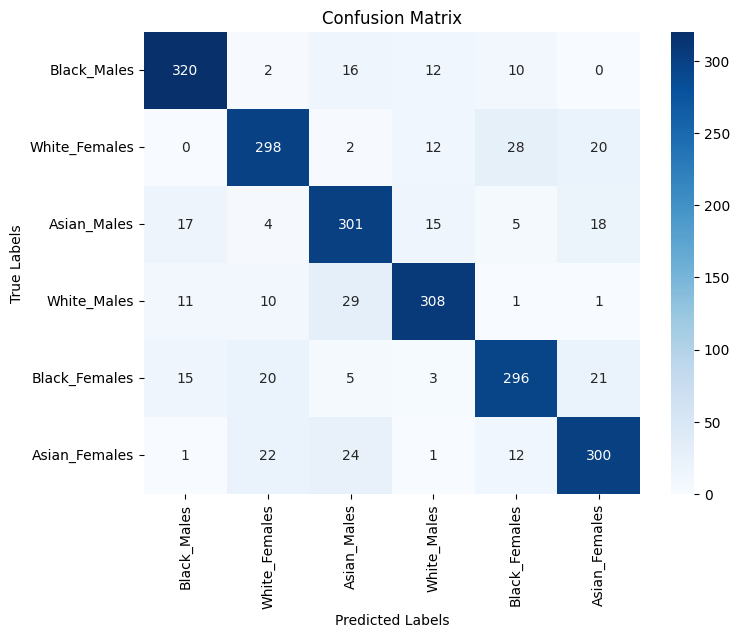

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
XGBClassifier,models/clf_demogpairs_xgb_vit-emotion-age_XGBClassifier.pkl,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.8439814814814814,0.8440640802455297,0.8443905534342058,0.8439814814814813,54


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_xgb_vit-emotion-age_',
    results_path='results/demogpairs_xgb_vit-emotion-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_xgb_vit-emotion-age_XGBClassifier.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 52463.0,
 'days': 0,
 'hours': 14,
 'minutes': 34,
 'seconds': 23.0,
 'text': '0 hari 14 jam 34 menit 23.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 463611.0,
 'days': 5,
 'hours': 8,
 'minutes': 46,
 'seconds': 51.0,
 'text': '5 hari 8 jam 46 menit 51.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.8513,0.8293,0.8391,0.8507,0.8507,0.8442,0.8442,0.8446,0.8442,244.6997
2,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}",0.8403,0.8374,0.8478,0.8455,0.8495,0.8441,0.8441,0.8448,0.8441,246.6318
3,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.8542,0.8316,0.8368,0.8432,0.8478,0.8427,0.8427,0.8434,0.8427,245.7462
4,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.8455,0.8252,0.8443,0.8455,0.8519,0.8425,0.8425,0.843,0.8425,250.011
...,...,...,...,...,...,...,...,...,...,...,...
51,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.8142,0.8148,0.8137,0.798,0.8223,0.8126,0.8125,0.813,0.8126,607.3394
52,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'approx'}",0.8206,0.8067,0.8171,0.7911,0.82,0.8111,0.8111,0.8117,0.8111,2845.7131
53,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.8027,0.7928,0.8119,0.8003,0.8137,0.8043,0.8043,0.8051,0.8043,509.3086
54,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.8009,0.8003,0.8061,0.7957,0.8079,0.8022,0.8022,0.8029,0.8022,2868.4455
